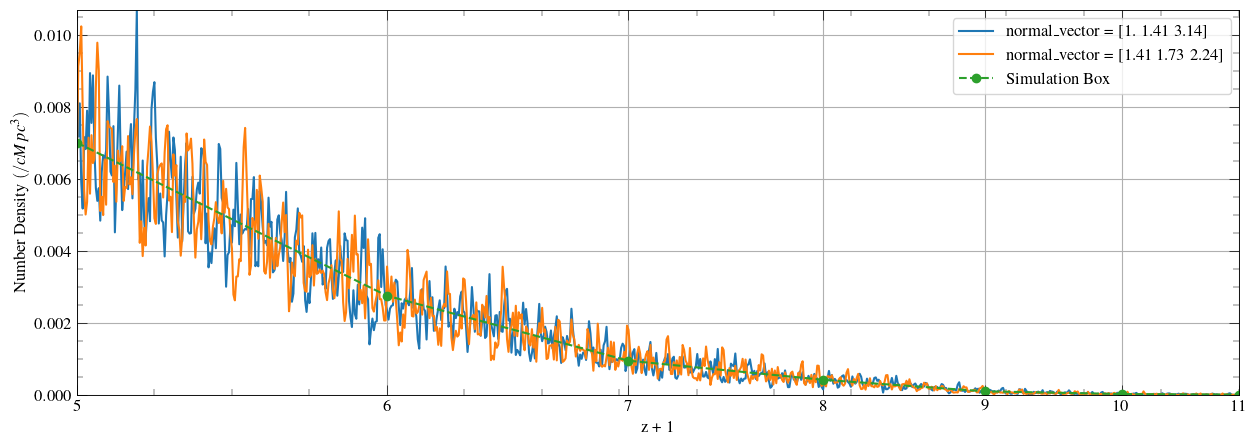

In [19]:
# 1) Load the 7 files which contains MBII black holes details in slices centered at 4, 5, 6, 7, 8, 9, 10 redshifts.
# 2) Extract the x, y, and z coordinates of the black holes.
# 3) Define the number of pixels in each dimension (50, 50, 1). and pixelated the data.
# 4) store each array which is n(x,y) for each redshift in a list called nz_arrays.


import numpy as np
import matplotlib.pyplot as plt
# Import interp1d
from scipy.interpolate import interp1d
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM


# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

# Define the redshifts
redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

nz_arrays = []

# defining the luminosity bin
min_lum = 0
max_lum = np.infty

BH_density = []

# Define the number of pixels in each dimension
num_pixels_x = 50
num_pixels_y = 50
num_pixels_z = 50

# Calculate the pixel size in each dimension
x_range = (0, 100000) #(np.min(x_coordinates), np.max(x_coordinates))
y_range = (0, 100000) #(np.min(y_coordinates), np.max(y_coordinates))
z_range = (0, 100000) #(np.min(z_coordinates), np.max(z_coordinates))

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = (z_range[1] - z_range[0]) / num_pixels_z

for file_path in file_paths:
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Extract the x, y, and z coordinates
    x_coordinates = data[:, 1]
    y_coordinates = data[:, 2]
    z_coordinates = data[:, 3]
    bh_lum = data[:, 8]

    # Find the black hole number density
    BH_density.append(len(data[:, 0]))

    # I want to introduce luminosity cuts at this point
    bh_lum_sol = bh_lum * 1.472 * 10 ** 12 # 1 M0/yr * 0.1 * c^2 equvialent to 1.472 x 10^12 L0

    # now get the indices of the black holes that are within the luminosity range
    ind_lum = np.where((bh_lum_sol >= min_lum) & (bh_lum_sol < max_lum))[0]

    x_coordinates = x_coordinates[ind_lum]
    y_coordinates = y_coordinates[ind_lum]
    z_coordinates = z_coordinates[ind_lum]   
    
    # Calculate the pixel indices for each coordinate
    pixel_indices_x = ((x_coordinates - x_range[0]) / pixel_size_x).astype(int)
    pixel_indices_y = ((y_coordinates - y_range[0]) / pixel_size_y).astype(int)
    pixel_indices_z = ((z_coordinates - z_range[0]) / pixel_size_z).astype(int)
    
    # Create an empty n(x, y, z) array
    n_array = np.zeros((num_pixels_x, num_pixels_y, num_pixels_z))
    L_array = np.zeros((num_pixels_x, num_pixels_y, num_pixels_z))
    
    # Count the number of particles in each pixel
    for i in range(len(x_coordinates)):
        n_array[pixel_indices_x[i], pixel_indices_y[i], pixel_indices_z[i]] += 1
        L_array[pixel_indices_x[i], pixel_indices_y[i], pixel_indices_z[i]] += bh_lum_sol[i]
    
    nz_arrays.append(n_array)

# Divide by the volume of the simulation box to get the number density
BH_density = np.array(BH_density) / (100**3)

# Remove the h^3 factor from the number density
BH_density = BH_density * h**3

# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h    

# Now each array in nz_arrays contains the n(x, y, z) for each redshift slice centered at 4, 5, 6, 7, 8, 9, 10.

# First convert the redshifts to comoving distances

# Calculate the comoving distances
new_z_axis = cosmo.comoving_distance(redshifts).value * h  # Convert to h^-1 Mpc

# These are the slice centers in the z direction for each redshift slice.

# Now I want to interpolate the data in nz_arrays to get the n(x, y, z) for any comoving distance in the range of new_z_axis.
sim_evolv_linear = interp1d(new_z_axis, nz_arrays, axis=0)

# Calculate the pixel size in each dimension in Mpch^-1
x_range = (0, 100) #(np.min(x_coordinates), np.max(x_coordinates))
y_range = (0, 100) #(np.min(y_coordinates), np.max(y_coordinates))
z_range = (0, 100) #(np.min(z_coordinates), np.max(z_coordinates))

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = (z_range[1] - z_range[0]) / num_pixels_z

# Now I want to make another 3d array which contains the n(x, y, z) for each comoving distance in the range of new_z_axis.
# Define the new z axis which has the resolution of the simulation box.

new_z_axis = np.arange(new_z_axis[0], new_z_axis[-1], pixel_size_z)

# Create an empty 3d array with shape same as the simulation along x and y
# and the length of the new z axis.

Lightcone = np.zeros((num_pixels_x, num_pixels_y, len(new_z_axis)))

# Now we need to fill the Lightcone array with the data from sim_evolv_linear, where when we move 1 comoving distance in the 
# z direction of the Lightcone array, we move 1 comoving distance in direction chosen at the start in the sim_evolv_linear array.

# We need a function of the following nature:
# Inputs: a

# This funcition finds the started plane of the simulation box given a normal vector and a center point.

from scipy.ndimage import map_coordinates

def create_rotated_plane(normal_vector, plane_center, num_pixels_plane):
    """
    Extract a 2D plane from a 3D array that makes an arbitrary angle with the axes.
    
    Parameters:
    array_3d (ndarray): The input 3D array.
    normal_vector (ndarray): A 3D vector normal to the plane.
    plane_center (ndarray): A 3D point representing the center of the plane.
    plane_size (tuple): The size of the plane in the form (width, height).
    plane_resolution (tuple): The resolution of the plane grid in the form (num_points_x, num_points_y).
    
    Returns:
    ndarray: A 2D array representing the extracted plane.
    """
    # Normalize the normal vector
    normal_vector = normal_vector / np.linalg.norm(normal_vector)
    
    # Create a grid of points in the plane
    x_size, y_size = num_pixels_plane
    x = np.arange(0, x_size)
    y = np.arange(0, y_size)
    xv, yv = np.meshgrid(x, y)
    
    # Create the plane basis vectors
    if np.all(normal_vector == [0, 0, 1]):
        u = np.array([1, 0, 0])
        v = np.array([0, 1, 0])
    else:
        u = np.cross(normal_vector, [0, 0, 1])
        u = u / np.linalg.norm(u)
        v = np.cross(normal_vector, u)
    
    # Transform plane points to 3D coordinates
    plane_points = plane_center[:, np.newaxis, np.newaxis] + u[:, np.newaxis, np.newaxis] * xv + v[:, np.newaxis, np.newaxis] * yv

    return plane_points

def trans_plane_points(normal_vector, plane_points):
    # This function transforms the plane points to the new plane points, translated alonged the normal vector by delattr.
    # Define the new plane points
    new_plane_points = plane_points + normal_vector[:, np.newaxis, np.newaxis]

    return new_plane_points

# calculate the volume of one slice z plane of the lightcone
volume = (x_range[1] - x_range[0]) * (y_range[1] - y_range[0]) * pixel_size_z

# Define the normal vector and center point of the plane
normal_vector = np.array([1,0.5,1]) #np.array([np.cos(np.radians(15)), np.sin(np.radians(15)), 0.1])

# Define the list of normal vectors
list_of_normal_vectors = [np.array([1, np.sqrt(2), np.pi]), np.array([np.sqrt(2), np.sqrt(3), np.sqrt(5)])]

# Define the center point of the plane
plane_center = np.array([20, 10, 5])

plane_size = (x_range[1], y_range[1])
plane_resolution = (pixel_size_x, pixel_size_y)

# Define the plot style
plt.style.use('MNRAS_Style.mplstyle')

# Define the figure size
plt.figure(figsize=(15, 5))

for normal_vector in list_of_normal_vectors:
    # Create the plane points
    plane_points = create_rotated_plane(normal_vector, plane_center, num_pixels_plane=(num_pixels_x, num_pixels_y))

    # Find the values from the simulation box corresponding to the plane.
    # grid wrap is used to apply periodic boundary conditions
    for i, r in enumerate(new_z_axis):
            # print(np.shape(plane_points))
            Lightcone[:,:,i] = map_coordinates(sim_evolv_linear(r), plane_points, order=1, mode='grid-wrap')

            # move the plane points along the normal vector by pixel_size_z.
            plane_points = trans_plane_points(normal_vector, plane_points)

    # Calculate the number density on lightcone
    number_density = np.sum(Lightcone, axis=(0, 1)) / volume

    # number density is in units of particles per Mpc/h^3. Convert it to particles per Mpc^3
    number_density = number_density * h**3

    # Convert redshifts to comoving distances
    red_com = cosmo.comoving_distance(redshifts).value * h

    # Plot the number density as a function of redshift
    plt.plot(new_z_axis, number_density, label='normal_vector = {}'.format(np.round(normal_vector, 2)))

# Calculate the number density on lightcone
number_density = np.sum(Lightcone, axis=(0, 1)) / volume

# number density is in units of particles per Mpc/h^3. Convert it to particles per Mpc^3
number_density = number_density * h**3

# Plot the BH density as a function of redshift with points
plt.plot(red_com, BH_density, 'o--', label='Simulation Box')

plt.ylabel(r"Number Density $(/cMpc^3)$")
# plt.title('Number Density as a Function of Redshift')
plt.legend()
# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)
plt.xlabel('z + 1')
plt.show()

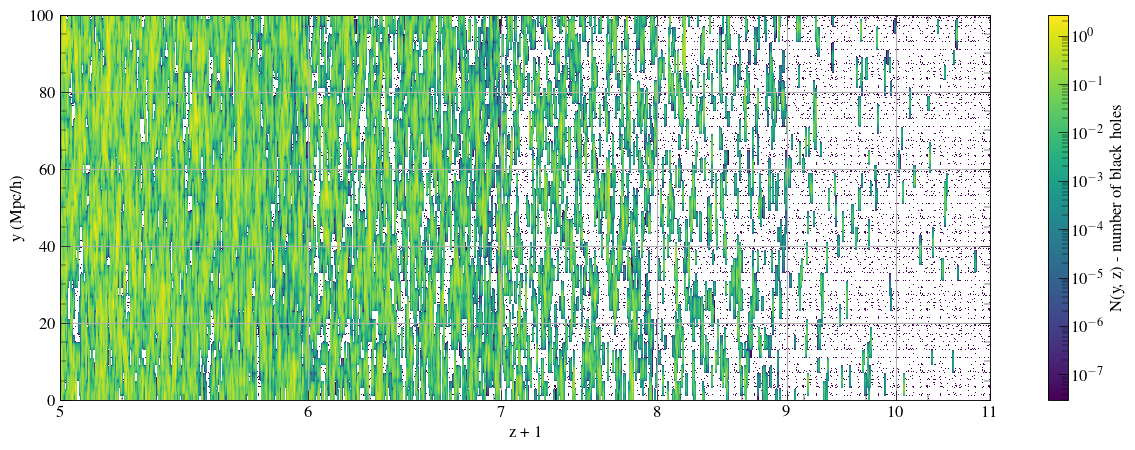

In [20]:
# sum over the x axis to get the 2d projection of the lightcone.
Lightcone_2d = np.average(Lightcone[25:30,:,:], axis=0) #np.sum(Lightcone, axis=0)

# Plot the 2d projection of the lightcone
# figure size

plt.style.use('MNRAS_Style.mplstyle')
plt.figure(figsize=(15, 5))
plt.imshow(Lightcone_2d, origin='lower',cmap='viridis', extent=[new_z_axis[0], new_z_axis[-1], x_range[0], x_range[1]], norm='log')
plt.xlabel('z (Mpc/h)')
plt.ylabel('y (Mpc/h)')
#give label to colorbar
plt.colorbar().set_label('N(y, z) - number of black holes')

# make the plot square
plt.gca().set_aspect('auto')
# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)
plt.xlabel('z + 1')

plt.show()

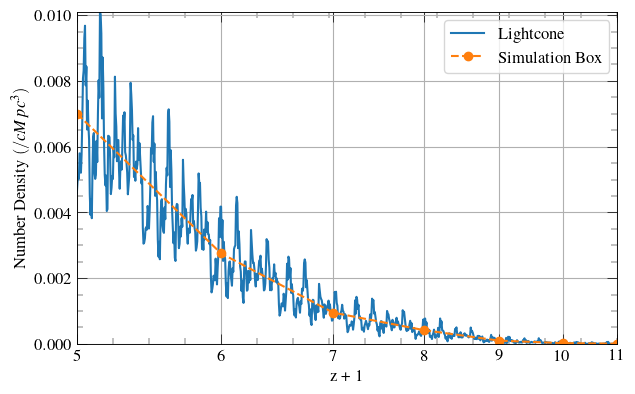

In [2]:
#  Make a plot of the number density of the lightcone as a function of redshift.
import numpy as np
import matplotlib.pyplot as plt
# Import interp1d
from scipy.interpolate import interp1d
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM

plt.style.use('MNRAS_Style.mplstyle')

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

# Define the number of pixels in each dimension
num_pixels_x = 50
num_pixels_y = 50
num_pixels_z = 50

# Calculate the pixel size in each dimension in Mpch^-1
x_range = (0, 100) #(np.min(x_coordinates), np.max(x_coordinates))
y_range = (0, 100) #(np.min(y_coordinates), np.max(y_coordinates))
z_range = (0, 100) #(np.min(z_coordinates), np.max(z_coordinates))

pixel_size_x = (x_range[1] - x_range[0]) / num_pixels_x
pixel_size_y = (y_range[1] - y_range[0]) / num_pixels_y
pixel_size_z = (z_range[1] - z_range[0]) / num_pixels_z

BH_density = []

# defining the luminosity bin
min_lum = 0
max_lum = np.infty

# Sum the black hole accretion rate in each simulation box

for file_path in file_paths:
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Find the black hole number density
    BH_density.append(len(data[:, 0]))

# Divide by the volume of the simulation box to get the number density
BH_density = np.array(BH_density) / (100**3)

# Remove the h^3 factor from the number density
BH_density = BH_density * h**3

# calculate the volume of one slice z plane of the lightcone
volume = (x_range[1] - x_range[0]) * (y_range[1] - y_range[0]) * pixel_size_z

# Calculate the number density on lightcone
number_density = np.sum(Lightcone, axis=(0, 1)) / volume

# number density is in units of particles per Mpc/h^3. Convert it to particles per Mpc^3
number_density = number_density * h**3

# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h

# Plot the number density as a function of redshift
plt.plot(new_z_axis, number_density, label='Lightcone')
# Plot the BH density as a function of redshift with points
plt.plot(red_com, BH_density, 'o--', label='Simulation Box')

plt.ylabel(r"Number Density $(/cMpc^3)$")
# plt.title('Number Density as a Function of Redshift')
plt.legend()
# Convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h # Convert to h^-1 Mpc

# remove the xticks and xticklabels
plt.xticks([])

# Now add the redcom values as xticks
plt.xticks(red_com, redshifts + 1)
plt.xlabel('z + 1')
plt.show()

In [12]:
plt.rcParams["figure.figsize"] 

[6.973848069738481, 4.310075139476229]

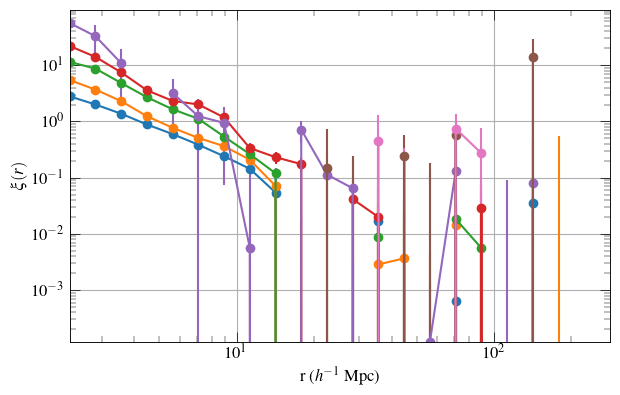

In [27]:
## Here I want to find the correlation function of the lightcone at redshifts 4, 5, 6, 7, 8, 9, 10.
## Lightcone used is 'bh_coordinates_lightcone_v3.npy' in "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import numpy.ma as ma
from Corrfunc.theory.DD import DD
from sklearn.neighbors import KernelDensity

# define the Data directory
DATA_DIRECTORY = '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/'
# define the Plot directory
PLOT_DIRECTORY = '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/'

# define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
h = 0.7

# Import the lightcone data
Lightcone = np.load('/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/bh_coordinates_lightcone_v3.npy')

# Extract the black hole coordinates
x_coordinates = Lightcone[:, 0]
y_coordinates = Lightcone[:, 1]
z_coordinates = Lightcone[:, 2]

x_coordinates_array = [0]*7
y_coordinates_array = [0]*7
z_coordinates_array = [0]*7

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])
# convert redshifts to comoving distances
red_com = cosmo.comoving_distance(redshifts).value * h

# For the case of redshift 4.
# comoving distance at redshift 4
com_dist4 = red_com[0]

# define a 100 Mpc/h box extending from com_dist4 to com_dist4 + 100 Mpc/h
com_dist4_end = com_dist4 + 100

# find the indices of the black holes that are within the box
ind4 = np.where((z_coordinates >= com_dist4) & (z_coordinates < com_dist4_end))[0]

# extract the x, y, z coordinates of the black holes within the box
x_coordinates_array[0] = x_coordinates[ind4]
y_coordinates_array[0] = y_coordinates[ind4]
z_coordinates_array[0] = z_coordinates[ind4]

# For the case of 5 to 9 redshifts
# comoving distance at redshift 5 to 9
for i in range(5):
    com_dist_start = red_com[i+1]
    com_dist_end = com_dist_start + 100

    # find the indices of the black holes that are within the box
    ind = np.where((z_coordinates >= com_dist_start) & (z_coordinates < com_dist_end))[0]

    # extract the x, y, z coordinates of the black holes within the box
    x_coordinates_array[i+1] = x_coordinates[ind]
    y_coordinates_array[i+1] = y_coordinates[ind]
    z_coordinates_array[i+1] = z_coordinates[ind]

# for the case of redshift 10
# comoving distance at redshift 10
com_dist10 = red_com[6]

# define a 100 Mpc/h box extending from com_dist10 - 100 Mpc/h to com_dist10
com_dist10_start = com_dist10 - 100

# find the indices of the black holes that are within the box
ind10 = np.where((z_coordinates >= com_dist10_start) & (z_coordinates < com_dist10))[0]

# extract the x, y, z coordinates of the black holes within the box
x_coordinates_array[6] = x_coordinates[ind10]
y_coordinates_array[6] = y_coordinates[ind10]
z_coordinates_array[6] = z_coordinates[ind10]

# Find the two point correlation function of the black holes at redshifts 4, 5, 6, 7, 8, 9, 10.
# Now I want to calculate the correlation function using the selected black holes and compare it with the correlation function using all black holes.
# Full balck holes correlation function.
corrfunc_data = []

for i in range(7):
    x_coordinates_sub = x_coordinates_array[i]
    y_coordinates_sub = y_coordinates_array[i]
    z_coordinates_sub = z_coordinates_array[i]

    min_x = 0
    max_x = 100 # h^-1 Mpc. Here x_coords, y_coords, z_coords are in h^-1 Mpc unlike the black holes coordinates directly from the MBII data.
    min_y = 0
    max_y = 100

    mult = 20 ## Number of random points used as a multiple of number of data points

    n_D = len(x_coordinates_sub)
    n_rand = mult * n_D
    rand_x = np.random.uniform(min_x, max_x, n_rand)
    rand_y = np.random.uniform(min_y, max_y, n_rand)

    #-------------------------------------------------------------------------------------------
    #Drawing random numbers for z from smoothed distribution of the data z vals

    z_bin_size = 0.1
    z_bin = np.arange(np.min(z_coordinates_sub), np.max(z_coordinates_sub), z_bin_size)[:,np.newaxis]
    z_bin_mid = (z_bin + z_bin_size/2)[:-1]
    kde = KernelDensity(kernel="gaussian", bandwidth=50).fit(z_coordinates_sub[:,np.newaxis])
    log_dens = kde.score_samples(z_bin_mid)
    pdf = np.exp(log_dens)
    # ax.fill(pos_z[:, 0], pdf, fc="#AAAAFF")
    cdf = np.cumsum(pdf)
    cdf = cdf / np.max(cdf)
    cdf = np.insert(cdf, 0, 0)

    z_bin = z_bin.flatten()
    z_bin_mid = z_bin_mid.flatten()

    uni_val = np.random.rand(n_rand)
    bin_indices = np.searchsorted(cdf, uni_val)
    bin_edges = z_bin[bin_indices - 1]
    bin_diff = z_bin[bin_indices] - z_bin[bin_indices-1]
    bin_weights = (uni_val - cdf[bin_indices-1]) / (cdf[bin_indices] - cdf[bin_indices-1])
    rand_z = bin_edges + bin_weights * bin_diff

    ## ---------------------------------------------------------------------------------------------------------------------------------------------------

    bins = np.logspace(start=np.log10(1.9868), stop=np.log10(314.915), num=23) #np.arange(0.01, 100, bin_size)
    bin_mids = (bins[0:-1] + bins[1:])/2

    result_DD = DD(autocorr=1, nthreads=1, binfile=bins, X1 = x_coordinates_sub, Y1 = y_coordinates_sub, Z1 = z_coordinates_sub, periodic=False)
    result_RR = DD(autocorr=1, nthreads=1, binfile=bins, X1 = rand_x, Y1 = rand_y, Z1 = rand_z, periodic=False)
    result_DR = DD(autocorr=0, nthreads=1, binfile=bins, X1 = x_coordinates_sub, Y1 = y_coordinates_sub, Z1 = z_coordinates_sub, X2 = rand_x, Y2 = rand_y, Z2 = rand_z, periodic=False)

    DD_norm = (n_D * (n_D - 1))/2
    RR_norm = (n_rand * (n_rand - 1))/2
    DR_norm = n_D * n_rand

    DD_count = result_DD['npairs']/2
    RR_count = result_RR['npairs']/2
    DR_count = result_DR['npairs']

    nil_pos = np.where(DD_count * RR_count * DR_count == 0)

    with np.errstate(divide='ignore', invalid='ignore'):
        LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)

    LandSzal2pcf = ma.array(LandSzal2pcf)
    LandSzal2pcf[nil_pos] = ma.masked

    with np.errstate(divide='ignore', invalid='ignore'):
        pois_err = (1 + LandSzal2pcf)/np.sqrt(np.minimum(DD_count, n_D))

    pois_err = ma.array(pois_err)
    pois_err[nil_pos] = ma.masked

    from pandas import DataFrame

    df = DataFrame({"r min":bins[0:-1], "r max":bins[1:], "DD count":DD_count, "DR count":DR_count, "RR count": RR_count, "Landy Szalay":LandSzal2pcf, "Pois Error":pois_err})

    #Save the data to a file
    df.to_csv(DATA_DIRECTORY + 'MBII_lc_corrfunc_z{}.csv'.format(redshifts[i]), index=False)

    corrfunc_data.append(df)

# Plot the correlation function
plt.style.use('MNRAS_Style.mplstyle')
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max'])/2
    plt.errorbar(corrfunc_data[i]['r mid'], corrfunc_data[i]['Landy Szalay'], yerr=corrfunc_data[i]['Pois Error'], fmt='.-', markersize=5, capsize=5, label='z = {}'.format(redshifts[i]))

plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ Mpc)')
# plt.ylim(-0.5, 10)
# plt.xlim(0, 150)
plt.legend()
plt.xscale('log')
plt.yscale('log')

# Save this plot as a pdf to Plot directory
# define the Plot directory
PLOT_DIRECTORY = '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/'
plt.savefig(PLOT_DIRECTORY + 'MBII_lc_corrfunc.pdf')

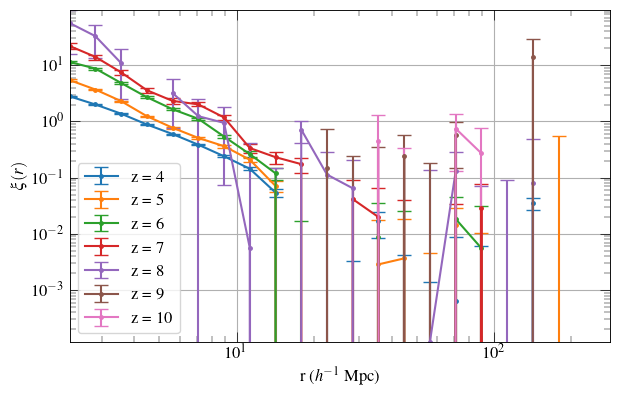

In [34]:
# Plot the correlation function
plt.style.use('MNRAS_Style.mplstyle')
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max'])/2
    plt.errorbar(corrfunc_data[i]['r mid'], corrfunc_data[i]['Landy Szalay'], yerr=corrfunc_data[i]['Pois Error'], fmt='.-', markersize=5, capsize=5, label='z = {}'.format(redshifts[i]))

plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ Mpc)')
# plt.ylim(-0.5, 10)
# plt.xlim(0, 150)
plt.legend()
plt.xscale('log')
plt.yscale('log')

# Save this plot as a pdf to Plot directory
# define the Plot directory
PLOT_DIRECTORY = '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/'
plt.savefig(PLOT_DIRECTORY + 'MBII_lc_corrfunc.pdf')

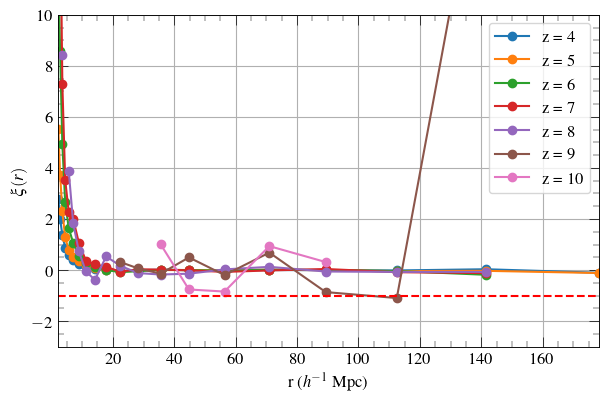

In [26]:
# Plot the correlation function using plt.plot without error bars
plt.style.use('MNRAS_Style.mplstyle')
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max'])/2
    plt.plot(corrfunc_data[i]['r mid'], corrfunc_data[i]['Landy Szalay'], 'o-', label='z = {}'.format(redshifts[i]))

plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ Mpc)')
plt.ylim(-3, 10)

# Draw horizontal line at y = -1
plt.axhline(y=-1, color='r', linestyle='--')

# plt.xlim(0, 150)
# plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()


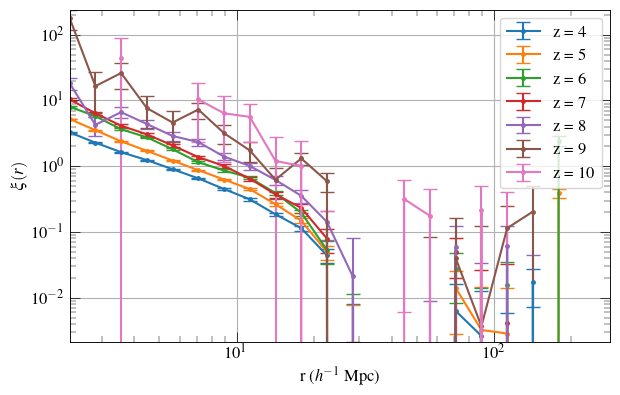

In [4]:
# read the data of correlation functions from Data directory
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# define the Data directory
DATA_DIRECTORY = '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/'
# define the Plot directory
PLOT_DIRECTORY = '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/'

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

corrfunc_data = []
for i in range(7):
    corrfunc_data.append(pd.read_csv(DATA_DIRECTORY + 'MBII_corrfunc_z{}.csv'.format(redshifts[i])))

# Plot the correlation function
plt.style.use('MNRAS_Style.mplstyle')
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max'])/2
    plt.errorbar(corrfunc_data[i]['r mid'], corrfunc_data[i]['Landy Szalay'], yerr=corrfunc_data[i]['Pois Error'], fmt='.-', markersize=5, capsize=5, label='z = {}'.format(redshifts[i]))

plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ Mpc)')
# plt.ylim(-0.5, 10)
# plt.xlim(0, 150)
plt.legend()
plt.xscale('log')
plt.yscale('log')

# Save this plot as a pdf to Plot directory
# define the Plot directory
PLOT_DIRECTORY = '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/'
# plt.savefig(PLOT_DIRECTORY + 'MBII_corrfunc_z4.pdf')